<a href="https://colab.research.google.com/github/Sebastian1657/SILaboratories/blob/main/SI_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [37]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs,zs))
print(inputs.shape)

(1000000, 2)


In [38]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 13*xs + 7 * zs - 12# + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000000, 1)


In [ ]:
# targets = targets.reshape(observations,)
# xs = xs.reshape(observations,)
# zs = zs.reshape(observations,)
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(xs,zs,targets)
# ax.set_xlabel('xs')
# ax.set_ylabel('zs')
# ax.set_zlabel('targets')
# ax.view_init(azim=100)
# plt.show()


In [39]:
init_range = 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)

[[-0.04946943]
 [-0.0931115 ]] [0.06379233]


In [40]:
targets = targets.reshape(observations,1)
# eta = 0.0001
# eta = 0.001
eta = 0.01
# eta = 1
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3753.9649703326136
1706.132529994309
795.902897090651
390.9042961731886
210.29683171976953
129.35765908795887
92.69634217699006
75.71335941601559
67.48362123881759
63.15494370468978
60.57216533214625
58.77789614379038
57.346690352491905
56.089347758046955
54.921591763031806
53.80574819025798
52.72484428890934
51.67110579439199
50.64084827956742
49.632208265253674
48.64413549393087
47.67594529902041
46.72711971953957
45.79721908669356
44.88584267385875
43.9926111378014
43.117158639263664
42.25912926387969
41.41817535450411
40.59395669397443
39.78614006708692
38.99439899247894
38.218413531433846
37.457870132282636
36.71246149202183
35.981886426955896
35.26584974869834
34.56406214387757
33.87624005678576
33.2021055746066
32.54138631503607
31.893815316186974
31.259130928706043
30.637076710047406
30.02740132085417
29.429858423403818
28.84420658207543
28.270209165798004
27.707634252440084
27.15625453510228
26.615847230274344
26.086193987820362
25.56708080275455
25.058297928773385
24.55963979

In [41]:
print(weights, biases)

[[13.00000009]
 [ 7.00000016]] [-11.99947936]


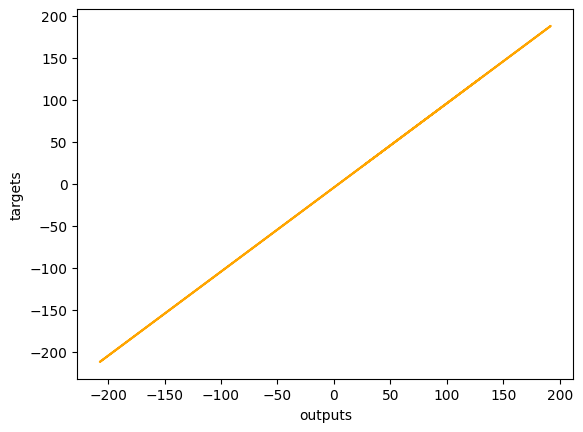

In [36]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()